### SVM Kernal Implementation

#### Dataset creation

In [1]:
## Importing the libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
## Outer coordinate points
x = np.linspace(-5.8,5.0,100)
y = np.sqrt(10**2 - x**2)
y = np.hstack([y,-y])
x = np.hstack([x,-x])

In [3]:
## Checking x values
x

array([-5.8       , -5.69090909, -5.58181818, -5.47272727, -5.36363636,
       -5.25454545, -5.14545455, -5.03636364, -4.92727273, -4.81818182,
       -4.70909091, -4.6       , -4.49090909, -4.38181818, -4.27272727,
       -4.16363636, -4.05454545, -3.94545455, -3.83636364, -3.72727273,
       -3.61818182, -3.50909091, -3.4       , -3.29090909, -3.18181818,
       -3.07272727, -2.96363636, -2.85454545, -2.74545455, -2.63636364,
       -2.52727273, -2.41818182, -2.30909091, -2.2       , -2.09090909,
       -1.98181818, -1.87272727, -1.76363636, -1.65454545, -1.54545455,
       -1.43636364, -1.32727273, -1.21818182, -1.10909091, -1.        ,
       -0.89090909, -0.78181818, -0.67272727, -0.56363636, -0.45454545,
       -0.34545455, -0.23636364, -0.12727273, -0.01818182,  0.09090909,
        0.2       ,  0.30909091,  0.41818182,  0.52727273,  0.63636364,
        0.74545455,  0.85454545,  0.96363636,  1.07272727,  1.18181818,
        1.29090909,  1.4       ,  1.50909091,  1.61818182,  1.72

In [4]:
## Checking y values
y

array([ 8.14616474,  8.22274612,  8.29718662,  8.36954337,  8.43986996,
        8.50821674,  8.57463104,  8.63915744,  8.70183794,  8.76271214,
        8.82181743,  8.87918915,  8.93486069,  8.98886363,  9.04122788,
        9.09198175,  9.14115207,  9.18876425,  9.23484239,  9.27940936,
        9.32248681,  9.36409531,  9.40425436,  9.44298244,  9.4802971 ,
        9.51621496,  9.55075178,  9.58392249,  9.61574123,  9.64622137,
        9.67537558,  9.70321579,  9.72975329,  9.75499872,  9.77896207,
        9.80165275,  9.82307959,  9.84325082,  9.86217417,  9.87985679,
        9.89630535,  9.91152597,  9.92552432,  9.93830556,  9.94987437,
        9.96023499,  9.96939117,  9.97734624,  9.98410307,  9.98966408,
        9.99403128,  9.99720622,  9.99919005,  9.99998347,  9.99958677,
        9.9979998 ,  9.995222  ,  9.99125237,  9.9860895 ,  9.97973153,
        9.97217617,  9.9634207 ,  9.95346196,  9.94229632,  9.92991973,
        9.91632763,  9.90151504,  9.88547645,  9.8682059 ,  9.84

In [5]:
## Inner coordinate points
x1 = np.linspace(-5.0,5.0,100)
y1 = np.sqrt(10**2-x1**2)
y1 = np.hstack([y1,-y1])
x1 = np.hstack([x1,-x1])

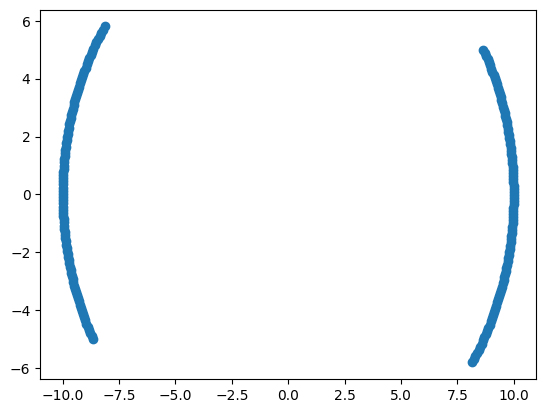

In [6]:
## Scatter plot as follows of the datapoints created : outer coordinates
plt.scatter(y,x)

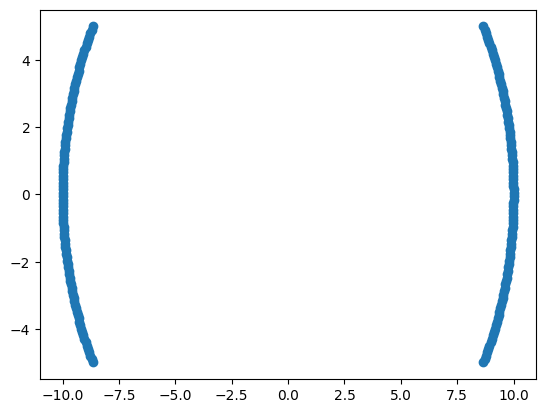

In [7]:
## Scatter plot as follows of the datapoints created : inner coordinates
plt.scatter(y1,x1)

In [8]:
## Example of h stack
a = [1,2,3]
b = [4,5,6]
np.hstack([a,b])

array([1, 2, 3, 4, 5, 6])

In [9]:
## Example of v stack
np.vstack([a,b]).T

array([[1, 4],
       [2, 5],
       [3, 6]])

In [10]:
## Creating the dataset

## Outer coordinate dataframe
df1 = pd.DataFrame(np.vstack([y,x]).T, columns = ['X1','X2'])
df1['Y'] = 0

## Inner coordinate dataframe
df2 = pd.DataFrame(np.vstack([y1,x1]).T, columns = ['X1','X2'])
df2['Y'] = 1

## Appending both the datasets
df = pd.concat([df1,df2], ignore_index = True)

## Checking the first 5 rows
df.head()

,X1,X2,Y
0,8.146165,-5.800000,0
1,8.222746,-5.690909,0
2,8.297187,-5.581818,0
3,8.369543,-5.472727,0
4,8.439870,-5.363636,0


In [11]:
## Checking the last 5 rows 
df.tail()

,X1,X2,Y
395,-8.881281,-4.59596,1
396,-8.828277,-4.69697,1
397,-8.773790,-4.79798,1
398,-8.717792,-4.89899,1
399,-8.660254,-5.00000,1


In [12]:
## Independednt and dependent features
X = df.iloc[:,:2]
y = df.Y

In [13]:
## Train and test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.25, random_state = 0)

Need to convert the data to polynomial

In [14]:
## Getting polynomial data
df['X1_square'] = df['X1']**2
df['X2_square'] = df['X2']**2
df['X1*X2'] = df['X1'] * df['X2']

## Checking the top 5 records
df.head()

,X1,X2,Y,X1_square,X2_square,X1*X2
0,8.146165,-5.800000,0,66.360000,33.640000,-47.247756
1,8.222746,-5.690909,0,67.613554,32.386446,-46.794901
2,8.297187,-5.581818,0,68.843306,31.156694,-46.313387
3,8.369543,-5.472727,0,70.049256,29.950744,-45.804228
4,8.439870,-5.363636,0,71.231405,28.768595,-45.268393


In [15]:
### Splitting to Independent and depended features
X = df[['X1','X2','X1_square','X2_square','X1*X2']]
y = df['Y']

In [16]:
## Train test split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.25, random_state = 0)

In [17]:
### Installing libraries and upgrading
# pip install plotly
# pip install --upgrade nbformat

In [18]:
## Importing library for plotting
import plotly.express as px

In [19]:
## Plotting the data - simple
fig = px.scatter_3d(df,x = 'X1',y='X2', z = 'X1*X2', color = 'Y')
fig.show()


In [20]:
## Plotting the data - polynomial
fig = px.scatter_3d(df, x = 'X1_square', y = 'X2_square', z = 'X1*X2', color = 'Y')
fig.show()

In [21]:
## Importing the libraries for SVC modelling
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

#### Linear kernel SVC

In [22]:
## Initializing the model
classifier = SVC(kernel = 'linear')

## Training the model
classifier.fit(X_train,y_train)

## Predicting the values
y_pred = classifier.predict(X_test)

In [23]:
## Accuracy of the SVC linear kernel model
accuracy_score(y_test,y_pred)

0.41

#### Polynomial Kernel in SVC

In [24]:
## Assigining the model
classifier1 = SVC(kernel='poly')

## Training the model
classifier1.fit(X_train,y_train)

## Predicting the values
y_pred1 = classifier1.predict(X_test)

In [25]:
## Accuracy of the model - SVC polynomial kernel
accuracy_score(y_test,y_pred1)

0.51

#### rbf kernel in SVC

In [26]:
## Initializing the model
classifier2 = SVC(kernel='rbf')

## Training the model
classifier2.fit(X_train, y_train)

## Predicting the values
y_pred2 = classifier2.predict(X_test)

In [27]:
## Accuracy of the model
accuracy_score(y_test,y_pred2)

0.52

#### Sigmoid kernel in SVC

In [28]:
## Initializing the model
classifier3 = SVC(kernel='sigmoid')

## Training the model
classifier3.fit(X_train,y_train)

## Predicting the values
y_pred3 = classifier3.predict(X_test)

In [29]:
## Accuracy of the model
accuracy_score(y_test,y_pred3)

0.45

- Out of all the model, rbf gives better, but accuracy is bad. 
- This can be improved with different kernels or with hyperparameter tuning

### Hyperparameter tuning

In [ ]:
## Importing grid search CV library
from sklearn.model_selection import GridSearchCV

In [1]:
## Defining the parameters
param_grid = {'C':[0.01,0.1,1,10,100,1000],
              'gamma':[1,0.1,0.01,0.001,0.0001],
              'kernel':['rbf','poly','sigmoid']}

In [42]:
## Defining grid search CV
grid = GridSearchCV(SVC(), param_grid = param_grid, refit = True, cv = 5, verbose = 3)

In [ ]:
## Training the model
grid.fit(X_train,y_train)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
[CV 1/5] END .C=0.0001, gamma=10000, kernel=rbf;, score=0.517 total time=   0.0s
[CV 2/5] END .C=0.0001, gamma=10000, kernel=rbf;, score=0.517 total time=   0.0s
[CV 3/5] END .C=0.0001, gamma=10000, kernel=rbf;, score=0.517 total time=   0.0s
[CV 4/5] END .C=0.0001, gamma=10000, kernel=rbf;, score=0.517 total time=   0.0s
[CV 5/5] END .C=0.0001, gamma=10000, kernel=rbf;, score=0.517 total time=   0.0s
[CV 1/5] END C=0.0001, gamma=10000, kernel=linear;, score=0.517 total time=   0.0s
[CV 2/5] END C=0.0001, gamma=10000, kernel=linear;, score=0.533 total time=   0.0s
[CV 3/5] END C=0.0001, gamma=10000, kernel=linear;, score=0.517 total time=   0.0s
[CV 4/5] END C=0.0001, gamma=10000, kernel=linear;, score=0.483 total time=   0.0s
[CV 5/5] END C=0.0001, gamma=10000, kernel=linear;, score=0.517 total time=   0.0s


In [ ]:
## Fining the best parameters
grid.best_params_

{'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}

In [ ]:
## Predicting the values
y_pred_grid = grid.predict(X_test)

In [ ]:
## Performance of the model
accuracy_score(y_test,y_pred_grid)

0.45

The accuracy of the model did not improve with hyperparameter tuning due to limited feature information. 